# Competitor Comparison

The purpose of this notebook is to compare the Robust Mixed Effects (RoME) algorithm to various competing algorithms.
This notebook contains three separate simulations that compare these methods.

In the first simulation, the standard Thompson sampling assumptions hold,
and the users are assumed to be homogeneous in the sense that their advantage functions (causal effects) are the same.

The second situation is similar, but users are heterogeneous in the sense that they have different advantage functions.

In the third simulation, the data-generating mechanism is much more complex.
In addition to being nonlinear, it also includes effects for users and time.
Consequently, only the RoME method performs well in this setting.

# Shared Setup

In [1]:
# Generic imports
import pandas as pd
import numpy as np
import scipy
import scipy.sparse
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
from river import linear_model
import copy
from multiprocessing import cpu_count
from joblib import Parallel, delayed
import pickle
import tensorflow as tf
import keras
from keras import layers, regularizers
import time

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 50)

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-w1zupg65 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2025-01-11 22:32:57.028760: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Imports from this project
from models.models import OracleTS, StandardTS, ActionCenteredTS, RoME, IntelligentPooling, UserLaplacian
from models.river_wrapper import RiverBatchEstimator
from models.bagging_mod import BaggingRegressor
from models.utils import find_neighbors
from simulations.data_generator import DataGenerator

In [3]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
plt.rcParams['font.family'] = 'sans-serif'

In [4]:
# Simulation setup: try some different values
N_STAGES = 200
N_OBSERVATIONS = N_STAGES * (N_STAGES + 1) // 2
N = N_STAGES
T = N_STAGES
THETA = np.array([1., 0.5, -4.])
CONTEXT_DIM = 2
EXTRA_CONTEXT_DIM = 2
LINEAR_BASELINE_COEF = np.array([2., -2., 3.])
THETA_TIME_INIT = np.array([-2., -4., 6.])
P = THETA.size
n_jobs = 25
REPS = 50
N_NEIGHBORS = 5

In [5]:
def get_max_norm(x):
    squared_norms = (x**2).sum(axis=1)
    norms = np.sqrt(squared_norms)
    max_norm = np.max(norms)
    return max_norm

def get_max_norm_for_pairs(x, pairs):
    x_diffs = x[pairs[0]] - x[pairs[1]]
    max_norm = get_max_norm(x_diffs)
    return max_norm

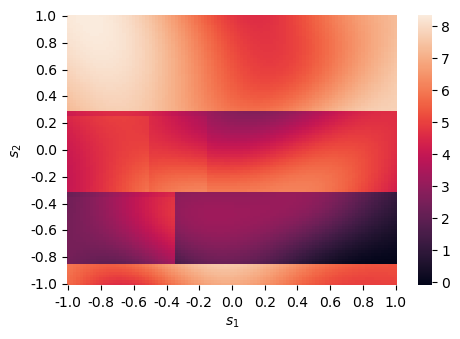

In [6]:
homogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="homogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
homogeneous_data_generator = homogeneous_data_generator.sample_theta(theta_base=THETA)

heterogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="heterogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
heterogeneous_data_generator = heterogeneous_data_generator.sample_theta(theta_base=THETA)

nonlinear_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="nonlinear", random_seed=3, nonlinear_scale=1.)  # Seed chosen for its interesting nonlinear relationships
nonlinear_data_generator = nonlinear_data_generator.sample_theta(theta_base=THETA, theta_time_init=THETA_TIME_INIT)

# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)
heatmap_min = np.min(baseline_vals)
heatmap_max = np.max(baseline_vals)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(baseline_vals_df, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/baseline_reward.png")
fig.savefig("figures/baseline_reward.pdf")
plt.show()

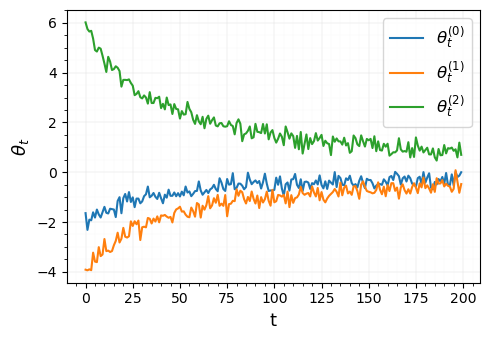

In [7]:
# Time-specifc thetas
fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(THETA.size):
    label = "$\\theta^{(idx)}_{t}$".replace("idx", str(i))
    ax.plot(nonlinear_data_generator.theta_time[:, i], alpha=1, label=label)
ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
ax.minorticks_on()
ax.set_xlabel("t", fontsize=13)
ax.set_ylabel("$\\theta_{t}$", fontsize=13)
# plt.title("Values of $\\theta_{time}$ Plotted Over Time")
ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig("figures/theta_time.png")
fig.savefig("figures/theta_time.pdf")
plt.show()

Epoch 1/20


2025-01-11 22:33:02.292725: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


200/200 [==============================] - 1s 2ms/step - loss: 1.5272 - val_loss: 1.0948
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0679 - val_loss: 1.0581
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0512 - val_loss: 1.0584
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0507 - val_loss: 1.0472
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0345 - val_loss: 1.0586
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0326 - val_loss: 1.0416
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0335 - val_loss: 1.0561
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0346 - val_loss: 1.0444
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0280 - val_loss: 1.0561
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0242 - val_loss: 1.0425
Epoch 11/2

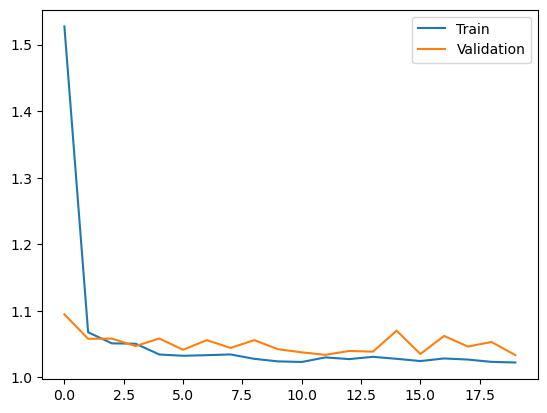

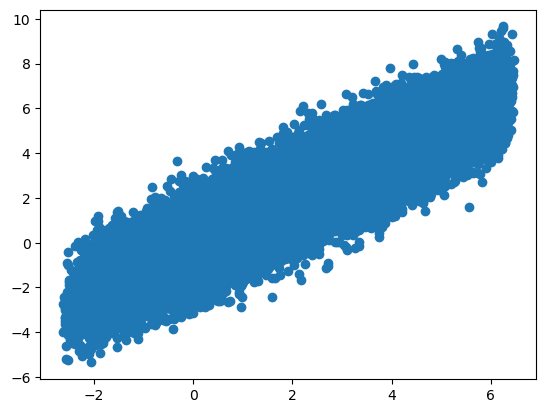

INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


Epoch 1/20
200/200 [==============================] - 1s 2ms/step - loss: 1.5620 - val_loss: 1.1742
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0786 - val_loss: 1.0890
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0682 - val_loss: 1.0649
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0558 - val_loss: 1.0663
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0504 - val_loss: 1.0459
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0532 - val_loss: 1.0804
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0460 - val_loss: 1.0418
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0448 - val_loss: 1.0465
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0473 - val_loss: 1.0458
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0450 - val_loss: 1.0540

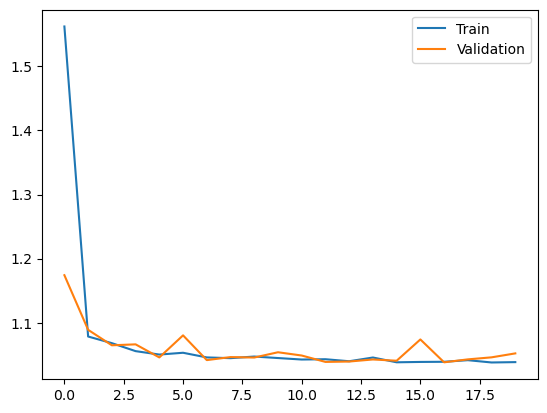

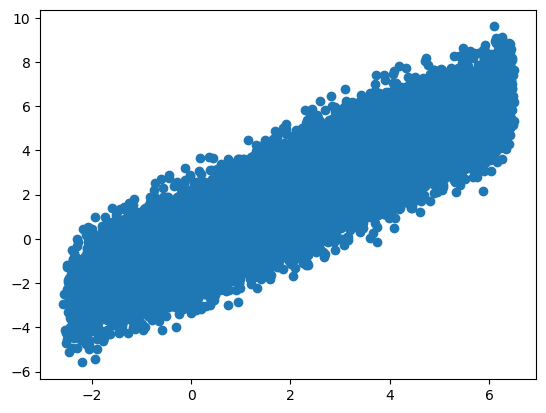

INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 4.5972 - val_loss: 2.7757
Epoch 2/50
200/200 [==============================] - 0s 1ms/step - loss: 2.2288 - val_loss: 1.7760
Epoch 3/50
200/200 [==============================] - 0s 1ms/step - loss: 1.6102 - val_loss: 1.4822
Epoch 4/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4927 - val_loss: 1.4551
Epoch 5/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4571 - val_loss: 1.4136
Epoch 6/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4575 - val_loss: 1.4419
Epoch 7/50
200/200 [==============================] - 0s 1ms/step - loss: 1.3960 - val_loss: 1.4109
Epoch 8/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4016 - val_loss: 1.3451
Epoch 9/50
200/200 [==============================] - 0s 1ms/step - loss: 1.3623 - val_loss: 1.3451
Epoch 10/50
200/200 [==============================] - 0s 1ms/step - loss: 1.3427 - val_loss: 1.3339

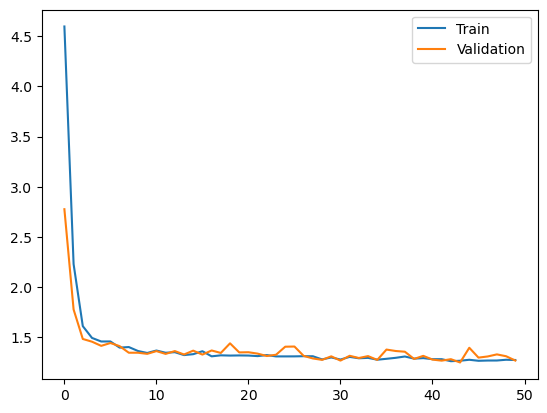

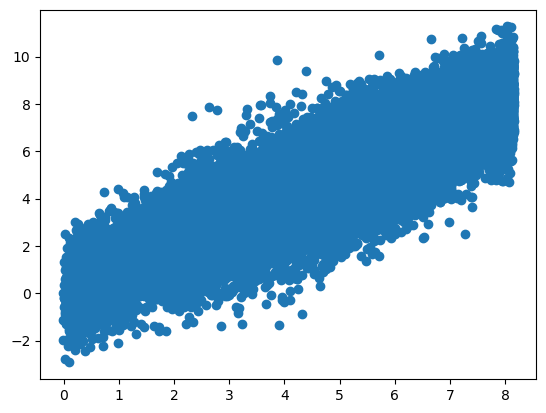

INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


In [8]:
# Neural network stuff
nn_input_dim = CONTEXT_DIM + EXTRA_CONTEXT_DIM

data_generators = [homogeneous_data_generator, heterogeneous_data_generator, nonlinear_data_generator]
model_files = ["tri-homogeneous-nn", "tri-heterogeneous-nn", "tri-nonlinear-nn"]
for i, (data_generator, model_file) in enumerate(zip(data_generators, model_files)):
    # Create data
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_train, y_train = data_generator.generate_baselines_for_nn()
    
    data_generator = data_generator.reset()
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_validation, y_validation = data_generator.generate_baselines_for_nn()
    
    # Train model
    penalty = 0.001
    nn_output_dim = 10
    model = keras.Sequential(
        [
            keras.Input(shape=(nn_input_dim,), name="input"),
            layers.Dense(10, activation="relu", name="layer1", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="relu", name="layer2", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="tanh", name="layer3", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(nn_output_dim, activation="tanh", name="layer4", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(1, name="output", kernel_regularizer=regularizers.l2(penalty)),
        ]
    )
    opt = keras.optimizers.Adam(learning_rate=0.01)
    model.compile(loss="mse", optimizer=opt)
    history = model.fit(
        X_train,
        y_train,
        batch_size=200,
        validation_data=(X_validation, y_validation),
        epochs=50 if i == 2 else 20,
        # epochs=1,
        verbose=1
    )
    
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.legend()
    plt.show()

    preds_validation = model(X_validation)
    plt.scatter(preds_validation, y_validation)
    plt.show()
    
    # Featurizer model
    featurizer_nn_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("layer4").output)
    featurizer_nn_model.compile()
    featurizer_nn_model.save(model_file)

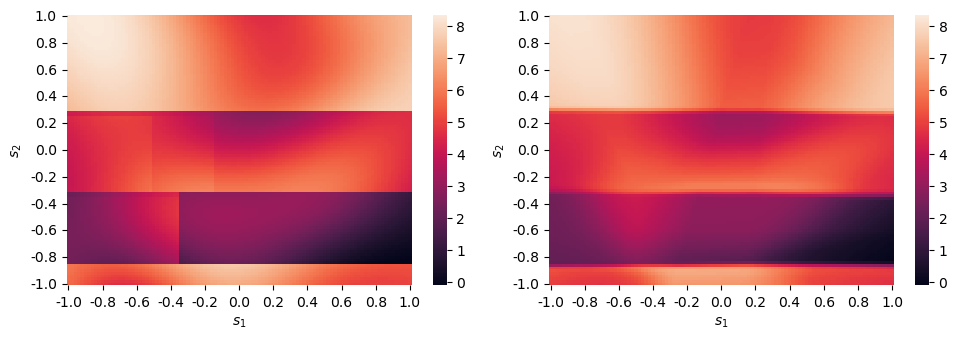

In [9]:
# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[0])
ax[0].set_xlabel("$s_{1}$")
ax[0].set_ylabel("$s_{2}$")

nn_context_values = np.hstack([context_values, np.zeros_like(context_values)])
nn_baseline_vals = model(nn_context_values).numpy()
nn_baseline_vals_df = pd.DataFrame(
    data=nn_baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[1])
ax[1].set_xlabel("$s_{1}$")
ax[1].set_ylabel("$s_{2}$")

fig.tight_layout()
fig.savefig("figures/nn_baseline_reward_comparison.png")
fig.savefig("figures/nn_baseline_reward_comparison.pdf")
plt.show()

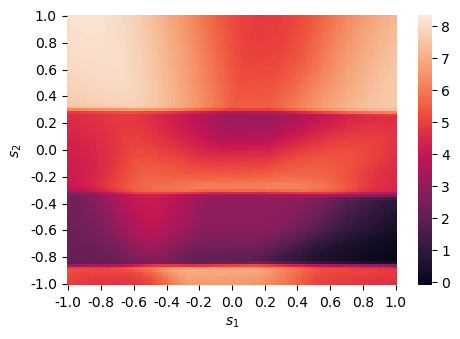

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/nn_baseline_reward.png")
fig.savefig("figures/nn_baseline_reward.pdf")
plt.show()

In [11]:
# This determines the plotting order
non_oracle_method_names = [
    "IntelPooling",
    "RoME-BLM",
    "RoME",
    "RoME-SU",
    "AC",
    "Standard",
    "Neural-Linear",
    "NNR-Linear"
]

def create_reward_dict(data_generator, nn_model_name, seed):
    np.random.seed(seed)
    user_pairs, L_user = find_neighbors(data_generator.theta_user, N_NEIGHBORS)
    time_pairs, L_time = find_neighbors(data_generator.theta_time, N_NEIGHBORS)
    
    bagged_lm = RiverBatchEstimator(
        BaggingRegressor(
            linear_model.LinearRegression(l2=1e-8, intercept_lr=0.1),
            n_models=10,
            subsample=0.8
        )
    )

    # Set covariances
    cov_epsilon = 1e-18
    user_cov = np.cov(data_generator.theta_user.T)
    if user_cov.sum() < cov_epsilon:
        user_cov += cov_epsilon * np.eye(user_cov.shape[0])
    time_cov = np.cov(data_generator.theta_time.T)
    if time_cov.sum() < cov_epsilon:
        time_cov += cov_epsilon * np.eye(time_cov.shape[0])

    nn = tf.keras.models.load_model(nn_model_name)
    nn_numpy = lambda x: nn(x).numpy()
    
    non_oracle_methods_dict = {
        "IntelPooling": IntelligentPooling(N, T, P, DataGenerator._featurize, user_cov=user_cov, time_cov=time_cov),
        "RoME": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS, delta=0.05),
        "RoME-BLM": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, ml_interactions=True, ml_model=bagged_lm, n_neighbors=N_NEIGHBORS, delta=0.05),
        "RoME-SU": RoME(1, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS, pool_users=False, delta=0.05),
        "AC": ActionCenteredTS(N, T, P, DataGenerator._featurize),
        "Standard": StandardTS(N, T, P, DataGenerator._featurize),
        "Neural-Linear": StandardTS(N, T, P, DataGenerator._featurize, nn=nn_numpy, nn_dim=nn_output_dim),
        "NNR-Linear": UserLaplacian(N, T, P, DataGenerator._featurize, L_user, user_cov=user_cov),
    }
    methods_dict = copy.copy(non_oracle_methods_dict)
    methods_dict["Oracle"] = OracleTS(N, T, THETA, data_generator.theta_user, data_generator.theta_time, DataGenerator._featurize)
    
    # Dictionary for storing rewards
    rewards_dict = {k:np.zeros((N, T)) for k in methods_dict}
    timings_dict = {}

    # Generate context vectors that we'll use for all models
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)

    # Iterate through methods
    for method_name, method in methods_dict.items():
        rewards = []
        data_generator = data_generator.reset()
        method.reset()
        method_start_time = time.time()

        while not data_generator.finished:
            # Randomly samples action from current policy
            context, context_extra, user_idx, time_idx = data_generator.get_current_context()
            action = method.sample_action(context, user_idx, time_idx)

            # Plays action and returns reward
            reward = data_generator.play_action(action)
            rewards_dict[method_name][user_idx, time_idx] = reward

            # Update method inferences
            method.update(context, context_extra, user_idx, time_idx, action, reward)
        method_end_time = time.time()
        method_elapsed_time = method_end_time - method_start_time
        timings_dict[method_name] = method_elapsed_time

    return rewards_dict, timings_dict

In [12]:
def run_simulation(data_generator, nn_model_name, REPS=REPS, n_jobs=cpu_count()):    
    # Perform whole simulation REPS times
    pool_args = zip(
        [copy.deepcopy(data_generator) for _ in range(REPS)],
        [nn_model_name]*REPS,
        range(REPS))
    print("Starting parallel")
    list_of_tuples_of_dicts = Parallel(n_jobs=n_jobs)(delayed(create_reward_dict)(*arg) for arg in pool_args)    
    print("Parallel closed")
    rewards_list_of_dicts = [t[0] for t in list_of_tuples_of_dicts]
    timings_list_of_dicts = [t[1] for t in list_of_tuples_of_dicts]
    rewards_dict = {}
    timings_dict = {}
    method_names = list(rewards_list_of_dicts[0].keys())
    non_oracle_method_names = list(set(method_names) - set(["Oracle"]))
    for method_name in method_names:
        rewards_dict[method_name] = np.asarray([
            rewards_list_of_dicts[i][method_name]
            for i in range(REPS)])
        timings_dict[method_name] = np.asarray([
            timings_list_of_dicts[i][method_name]
            for i in range(REPS)])
                
    return rewards_dict, timings_dict

In [13]:
def get_avg_stage_reward(a):
    means = [a[:, ::-1].diagonal(i, axis1=1, axis2=2).mean(axis=1) for i in range(-a.shape[1]+1,a.shape[2])]
    return np.asarray(means)[:a.shape[1]]


def plot_rewards_dict(rewards_dict, assumptions):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax0 = ax[0]
    ax1 = ax[1]
    
    # Calculate incremental regret
    oracle_incremental_regret = get_avg_stage_reward(rewards_dict["Oracle"])
    incremental_regret_dict = {
        method_name: (oracle_incremental_regret - get_avg_stage_reward(rewards_dict[method_name])).mean(axis=1)  # Mean over reps
        for method_name in non_oracle_method_names}

    # Calculate cumulative regret
    cumulative_regret_dict = {method_name: np.cumsum(incremental_regret_dict[method_name]) for method_name in non_oracle_method_names}

    # Plot incremental regret
    for method_name in non_oracle_method_names:
        ax0.plot(incremental_regret_dict[method_name], label=method_name, )
    ax0.set_title("(a) Incremental Regret Over Time", pad=10)
    ax0.set_ylabel("Incremental Regret")
    ax0.set_xlabel("Stage")
    ax0.legend()

    # Plot cumulative regret
    for method_name in non_oracle_method_names:
        ax1.plot(cumulative_regret_dict[method_name], label=method_name)
    ax1.set_title("(b) Cumulative Regret Over Time", pad=10)
    ax1.set_ylabel("Cumulative Regret")
    ax1.set_xlabel("Stage")
    plt.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.savefig(f"figures/{assumptions}-regret.png")
    fig.savefig(f"figures/{assumptions}-regret.pdf")
    fig.suptitle(f"Regret for {assumptions.capitalize()} Data-Generating Process")
    plt.show()

# Simulation 1: Homogeneous Users, Linear Baseline, No Time Effects

In [14]:
homogeneous_rewards_dict, homogeneous_timings_dict = run_simulation(homogeneous_data_generator, model_files[0], n_jobs=n_jobs)

Starting parallel


2025-01-11 22:33:35.693921: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:33:35.697425: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 22:33:35.700938: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [15]:
def print_timings(timings_dict_):
    print("Average elapsed time by method")
    for k in timings_dict_:
        mean_timing = timings_dict_[k].mean()
        print(f"{k}: {mean_timing}")
    timings_df = pd.DataFrame(timings_dict_)
    print(timings_df)
    return timings_df
print_timings(homogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 46.2280354309082
RoME: 394.39772555828097
RoME-BLM: 94.5354932308197
RoME-SU: 384.04167142868044
AC: 0.11545090675354004
Standard: 0.16017082691192627
Neural-Linear: 0.720452961921692
NNR-Linear: 29.76507559299469
Oracle: 0.019544010162353517
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      47.856014  372.781116   96.998873  368.368420  0.114940  0.158537   
1      50.428434  389.969447   92.270139  379.084022  0.118563  0.162815   
2      48.458995  361.082724   93.059916  359.451185  0.117743  0.161606   
3      46.457990  360.732301   94.593344  361.102977  0.115407  0.159361   
4      47.345154  368.833018   95.384593  364.622954  0.116022  0.160311   
5      48.014272  363.629599   96.528725  356.711348  0.114208  0.159088   
6      49.643645  368.134181   96.518962  373.579774  0.113471  0.158656   
7      47.195087  368.459652  100.364986  368.865828  0.115186  0.160315   
8      47.953737  373.912951

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,47.856014,372.781116,96.998873,368.368420,0.114940,0.158537,0.723423,29.714082,0.019673
1,50.428434,389.969447,92.270139,379.084022,0.118563,0.162815,0.805096,30.694149,0.019536
2,48.458995,361.082724,93.059916,359.451185,0.117743,0.161606,0.752509,30.151498,0.020563
3,46.457990,360.732301,94.593344,361.102977,0.115407,0.159361,0.736807,29.449773,0.018492
4,47.345154,368.833018,95.384593,364.622954,0.116022,0.160311,0.756648,29.576623,0.019166
5,48.014272,363.629599,96.528725,356.711348,0.114208,0.159088,0.735453,29.408950,0.019805
6,49.643645,368.134181,96.518962,373.579774,0.113471,0.158656,0.732472,29.605325,0.018605
7,47.195087,368.459652,100.364986,368.865828,0.115186,0.160315,0.745049,29.378723,0.018348
8,47.953737,373.912951,96.586727,365.568024,0.115625,0.159377,0.758396,29.909391,0.019207
9,47.749586,374.393081,97.360991,361.822432,0.114922,0.159334,0.745284,29.929422,0.020309


In [16]:
homogeneous_rewards_filename = "checkpoints/homogeneous_rewards.pkl"
with open(homogeneous_rewards_filename, 'wb') as file:
    pickle.dump(homogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
with open(homogeneous_rewards_filename, "rb") as file:
    homogeneous_rewards_dict = pickle.load(file)

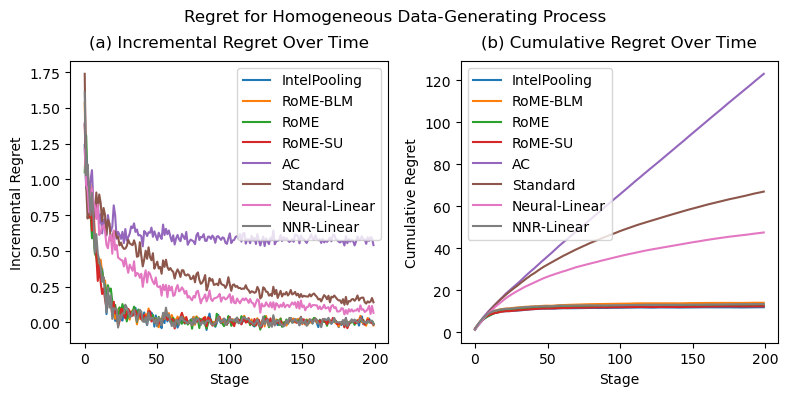

In [18]:
plot_rewards_dict(homogeneous_rewards_dict, "homogeneous")

# Simulation 2: Heterogeneous Users, Linear Baseline, No Time Effects

In [19]:
heterogeneous_rewards_dict, heterogeneous_timings_dict = run_simulation(heterogeneous_data_generator, model_files[1], n_jobs=n_jobs)

Starting parallel


2025-01-11 23:07:35.426131: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:07:35.466794: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:07:35.495945: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [20]:
print_timings(heterogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 42.460102777481076
RoME: 417.254035654068
RoME-BLM: 97.52175940513611
RoME-SU: 398.96801795005797
AC: 0.1164105463027954
Standard: 0.16318501472473146
Neural-Linear: 0.7518143320083618
NNR-Linear: 31.75939404964447
Oracle: 0.01932809829711914
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      40.971203  366.564471   99.971804  378.070586  0.116183  0.160452   
1      41.730498  370.609187   98.070090  386.550062  0.114529  0.158270   
2      42.715087  371.370309   98.567305  382.810886  0.115613  0.161235   
3      41.869848  382.576148   98.969996  391.390016  0.116928  0.161760   
4      41.059144  365.279395   98.594814  372.265264  0.117235  0.162255   
5      40.632818  360.494567   97.140128  369.597346  0.116268  0.161680   
6      39.892941  370.138725   96.125268  375.207345  0.115186  0.159559   
7      40.659781  375.598253   97.116183  382.261347  0.118122  0.167137   
8      42.535411  378.584038

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,40.971203,366.564471,99.971804,378.070586,0.116183,0.160452,0.819053,30.770944,0.018910
1,41.730498,370.609187,98.070090,386.550062,0.114529,0.158270,0.761585,31.201909,0.019285
2,42.715087,371.370309,98.567305,382.810886,0.115613,0.161235,0.826957,31.244381,0.018682
3,41.869848,382.576148,98.969996,391.390016,0.116928,0.161760,0.780735,31.522309,0.020116
4,41.059144,365.279395,98.594814,372.265264,0.117235,0.162255,0.800624,31.421642,0.018940
5,40.632818,360.494567,97.140128,369.597346,0.116268,0.161680,0.830510,31.430491,0.018774
6,39.892941,370.138725,96.125268,375.207345,0.115186,0.159559,0.768162,30.856620,0.018760
7,40.659781,375.598253,97.116183,382.261347,0.118122,0.167137,0.821599,31.689131,0.018834
8,42.535411,378.584038,105.170364,371.480628,0.115577,0.162201,0.812151,33.955550,0.020027
9,41.165409,376.019984,96.434811,376.127324,0.115243,0.160455,0.751563,30.606582,0.018463


In [21]:
heterogeneous_rewards_filename = "checkpoints/heterogeneous_rewards.pkl"
with open(heterogeneous_rewards_filename, 'wb') as file:
    pickle.dump(heterogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
with open(heterogeneous_rewards_filename, "rb") as file:
    heterogeneous_rewards_dict = pickle.load(file)

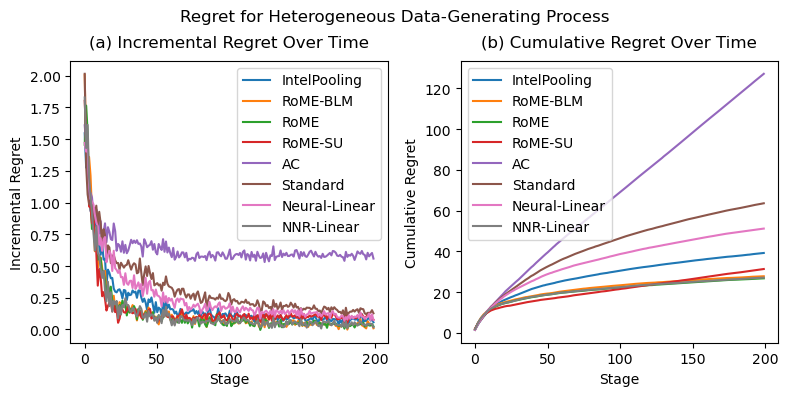

In [23]:
plot_rewards_dict(heterogeneous_rewards_dict, "heterogeneous")

# Simulation 3: Nonlinear Baseline and User-/Time-specific Effects

In [24]:
nonlinear_rewards_dict, nonlinear_timings_dict = run_simulation(nonlinear_data_generator, model_files[2], n_jobs=n_jobs)

Starting parallel


2025-01-11 23:52:15.897617: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:52:16.372717: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 23:52:16.378754: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [25]:
print_timings(nonlinear_timings_dict)

Average elapsed time by method
IntelPooling: 47.33322426319123
RoME: 427.6592083787918
RoME-BLM: 113.71614944458008
RoME-SU: 404.26227763652804
AC: 0.2618830156326294
Standard: 0.30985398292541505
Neural-Linear: 0.8955966472625733
NNR-Linear: 31.997308492660522
Oracle: 0.15699001312255859
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      46.881093  388.187838  112.622915  372.240922  0.261540  0.311094   
1      45.243523  389.540210  112.376649  369.515763  0.254971  0.298850   
2      45.784440  384.960634  113.932498  370.655062  0.257748  0.301176   
3      46.201019  392.490736  112.440215  377.435650  0.253103  0.296001   
4      46.212389  396.472787  112.653937  380.043072  0.258376  0.298388   
5      45.659178  400.276235  112.352977  384.614525  0.267740  0.308985   
6      46.071106  392.589932  111.813147  386.347347  0.257177  0.302365   
7      46.357960  395.798419  112.564063  378.341529  0.253422  0.294745   
8      45.684321  381.6133

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,46.881093,388.187838,112.622915,372.240922,0.261540,0.311094,0.900883,31.848860,0.157751
1,45.243523,389.540210,112.376649,369.515763,0.254971,0.298850,0.883873,31.464590,0.155203
2,45.784440,384.960634,113.932498,370.655062,0.257748,0.301176,0.907669,31.564904,0.157919
3,46.201019,392.490736,112.440215,377.435650,0.253103,0.296001,0.904052,31.266883,0.153123
4,46.212389,396.472787,112.653937,380.043072,0.258376,0.298388,0.897618,31.948698,0.155946
5,45.659178,400.276235,112.352977,384.614525,0.267740,0.308985,0.937752,32.052030,0.165942
6,46.071106,392.589932,111.813147,386.347347,0.257177,0.302365,0.930010,31.105471,0.157170
7,46.357960,395.798419,112.564063,378.341529,0.253422,0.294745,0.883296,30.893093,0.158436
8,45.684321,381.613376,111.770661,370.986983,0.257344,0.300599,0.882018,31.341675,0.158207
9,46.181810,395.306473,112.657865,381.872319,0.255975,0.300770,0.894939,31.657267,0.156773


In [26]:
nonlinear_rewards_filename = "checkpoints/nonlinear_rewards.pkl"
with open(nonlinear_rewards_filename, 'wb') as file:
    pickle.dump(nonlinear_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [27]:
with open(nonlinear_rewards_filename, "rb") as file:
    nonlinear_rewards_dict = pickle.load(file)

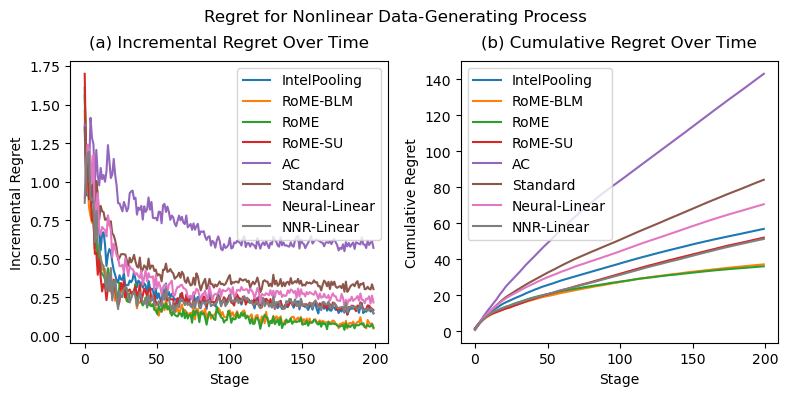

In [28]:
plot_rewards_dict(nonlinear_rewards_dict, "nonlinear")

# Cumulative Regret for All Three Settings

## Calculations

In [29]:
# Calculate incremental regret
incremental_homogeneous_regret_dict = {
    method_name: get_avg_stage_reward(homogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(homogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_heterogeneous_regret_dict = {
    method_name: get_avg_stage_reward(heterogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(heterogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_nonlinear_regret_dict = {
    method_name: get_avg_stage_reward(nonlinear_rewards_dict["Oracle"]) - get_avg_stage_reward(nonlinear_rewards_dict[method_name])
    for method_name in non_oracle_method_names}

# Calculate cumulative regret
cumulative_homogeneous_regret_dict = {method_name: np.cumsum(incremental_homogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_heterogeneous_regret_dict = {method_name: np.cumsum(incremental_heterogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_nonlinear_regret_dict = {method_name: np.cumsum(incremental_nonlinear_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}

# Final regret
final_homogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_homogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_homogeneous_regret_df.to_csv("./checkpoints/final_homogeneous_regret.csv", index=False)

final_heterogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_heterogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_heterogeneous_regret_df.to_csv("./checkpoints/final_heterogeneous_regret.csv", index=False)

final_nonlinear_regret_df = pd.DataFrame({
    method_name: cumulative_nonlinear_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_nonlinear_regret_df.to_csv("./checkpoints/final_nonlinear_regret.csv", index=False)

## Plots

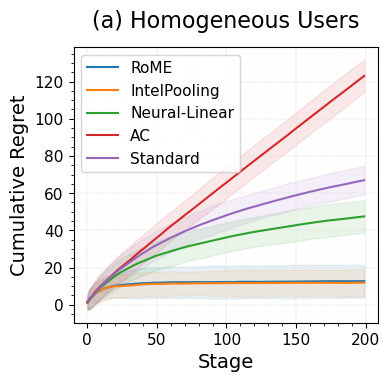

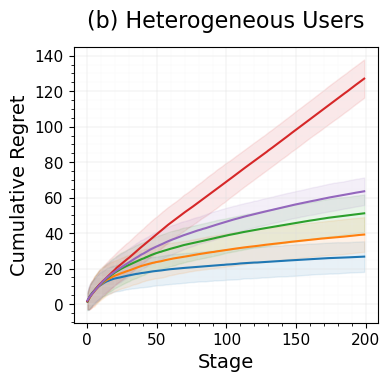

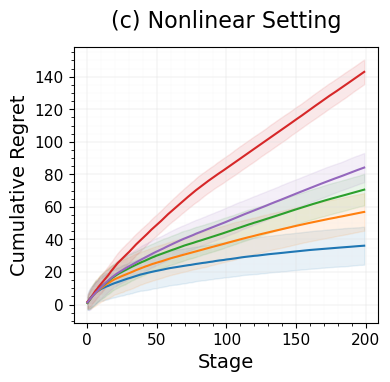

In [30]:
def plot_cumulative_regret(cumulative_regret_dict, setting_name, include_legend=False, loc="main", include_bands=True):
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    for i, method_name in enumerate(cumulative_regret_dict.keys()):
        color_i = f"C{i}"
        method_means = cumulative_regret_dict[method_name].mean(axis=1)
        method_range = np.arange(method_means.size)
        method_sds = cumulative_regret_dict[method_name].std(axis=1)
        method_lower = method_means - 1.96 * method_sds
        method_upper = method_means + 1.96 * method_sds
        if include_bands:
            ax.fill_between(method_range, method_lower, method_upper, color=color_i, alpha=0.1)
        ax.plot(method_range, method_means, label=method_name, color=color_i)
        
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
    ax.minorticks_on()
    ax.set_title(setting_name, pad=14, fontsize=16)
    ax.set_ylabel("Cumulative Regret", fontsize=14)
    ax.set_xlabel("Stage", fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    if include_legend:
        ax.legend(fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    setting_name_for_file = setting_name.replace("(", "").replace(")", "").replace(" ", "-")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.png")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.pdf")
    # fig.suptitle("Comparison of Cumulative Regret by Method")
    plt.show()

main_paper_methods = ["RoME", "IntelPooling", "Neural-Linear", "AC", "Standard"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(a) Homogeneous Users", include_legend=True)

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False)

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in main_paper_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False)

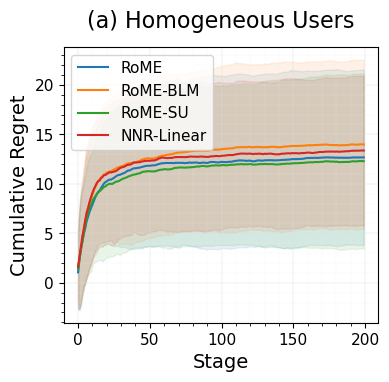

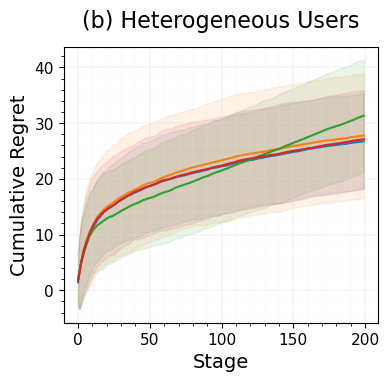

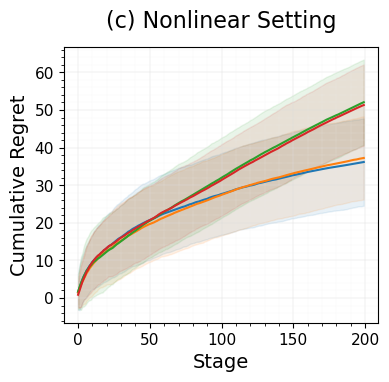

In [31]:
appendix_methods = ["RoME", "RoME-BLM", "RoME-SU", "NNR-Linear"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(a) Homogeneous Users", include_legend=True, loc="app")

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False, loc="app")

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in appendix_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False, loc="app")

## Comparison Tables

### Extra

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
final_homogeneous_regret_df = pd.read_csv("./checkpoints/final_homogeneous_regret.csv")
final_heterogeneous_regret_df = pd.read_csv("./checkpoints/final_heterogeneous_regret.csv")
final_nonlinear_regret_df = pd.read_csv("./checkpoints/final_nonlinear_regret.csv")

In [34]:
non_oracle_method_names_sorted = [
    'RoME',
    'RoME-BLM',
    'RoME-SU',
    'NNR-Linear',
    'IntelPooling',
    'Neural-Linear',
    'Standard',
    'AC',
]

In [35]:
def create_comparison_df(final_regret_df):
    comparison_outer_list = []
    win_percentages = []
    for method_row in non_oracle_method_names_sorted:
        comparison_inner_list = []
        win_percentage = 0.
        for method_column in non_oracle_method_names_sorted:
            diffs = final_regret_df[method_column] - final_regret_df[method_row]
            percent_row_better = np.mean(diffs > 0)
            avg_diff = np.mean(diffs)
            p_value = ttest_1samp(diffs, popmean=0).pvalue
            if method_row == method_column:
                cell_text = "-"
            else:
                win_percentage += percent_row_better / (len(non_oracle_method_names_sorted) - 1)
                cell_text = f"{percent_row_better:.0%}{'*' if p_value < 0.05 else ''}"
            comparison_inner_list.append(cell_text)
        comparison_outer_list.append(comparison_inner_list)
        win_percentages.append(f"{win_percentage:.0%}")
    comparison_df = pd.DataFrame(
        comparison_outer_list,
        index=[f"{i+1}. {n}" for i, n in enumerate(non_oracle_method_names_sorted)],
        columns=range(1, len(non_oracle_method_names_sorted)+1))
    comparison_df["\textbf{Avg}"] = win_percentages
    latex_table = comparison_df.to_latex(escape=False).replace("%", "\%")
    print(latex_table)
    return comparison_df

In [36]:
homogeneous_comparison_df = create_comparison_df(final_homogeneous_regret_df)
homogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 58\% & 50\% & 66\% & 38\% & 100\%* & 100\%* & 100\%* & 73\% \\
2. RoME-BLM & 42\% & - & 38\%* & 42\% & 36\%* & 100\%* & 100\%* & 100\%* & 65\% \\
3. RoME-SU & 50\% & 62\%* & - & 58\% & 42\% & 100\%* & 100\%* & 100\%* & 73\% \\
4. NNR-Linear & 34\% & 58\% & 42\% & - & 32\%* & 100\%* & 100\%* & 100\%* & 67\% \\
5. IntelPooling & 62\% & 64\%* & 58\% & 68\%* & - & 100\%* & 100\%* & 100\%* & 79\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 14\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,58%,50%,66%,38%,100%*,100%*,100%*,73%
2. RoME-BLM,42%,-,38%*,42%,36%*,100%*,100%*,100%*,65%
3. RoME-SU,50%,62%*,-,58%,42%,100%*,100%*,100%*,73%
4. NNR-Linear,34%,58%,42%,-,32%*,100%*,100%*,100%*,67%
5. IntelPooling,62%,64%*,58%,68%*,-,100%*,100%*,100%*,79%
6. Neural-Linear,0%*,0%*,0%*,0%*,0%*,-,100%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,0%*,-,100%*,14%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [37]:
heterogeneous_comparison_df = create_comparison_df(final_heterogeneous_regret_df)
heterogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 48\% & 82\%* & 54\% & 100\%* & 100\%* & 100\%* & 100\%* & 83\% \\
2. RoME-BLM & 52\% & - & 72\%* & 52\% & 100\%* & 100\%* & 100\%* & 100\%* & 82\% \\
3. RoME-SU & 18\%* & 28\%* & - & 20\%* & 92\%* & 100\%* & 100\%* & 100\%* & 65\% \\
4. NNR-Linear & 46\% & 48\% & 80\%* & - & 100\%* & 100\%* & 100\%* & 100\%* & 82\% \\
5. IntelPooling & 0\%* & 0\%* & 8\%* & 0\%* & - & 96\%* & 100\%* & 100\%* & 43\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 96\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 4\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,48%,82%*,54%,100%*,100%*,100%*,100%*,83%
2. RoME-BLM,52%,-,72%*,52%,100%*,100%*,100%*,100%*,82%
3. RoME-SU,18%*,28%*,-,20%*,92%*,100%*,100%*,100%*,65%
4. NNR-Linear,46%,48%,80%*,-,100%*,100%*,100%*,100%*,82%
5. IntelPooling,0%*,0%*,8%*,0%*,-,96%*,100%*,100%*,43%
6. Neural-Linear,0%*,0%*,0%*,0%*,4%*,-,96%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,4%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


### Nonlinear Setting

In [38]:
nonlinear_comparison_df = create_comparison_df(final_nonlinear_regret_df)
nonlinear_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 56\% & 100\%* & 98\%* & 98\%* & 100\%* & 100\%* & 100\%* & 93\% \\
2. RoME-BLM & 44\% & - & 94\%* & 98\%* & 100\%* & 100\%* & 100\%* & 100\%* & 91\% \\
3. RoME-SU & 0\%* & 6\%* & - & 40\% & 78\%* & 100\%* & 100\%* & 100\%* & 61\% \\
4. NNR-Linear & 2\%* & 2\%* & 60\% & - & 82\%* & 100\%* & 100\%* & 100\%* & 64\% \\
5. IntelPooling & 2\%* & 0\%* & 22\%* & 18\%* & - & 98\%* & 100\%* & 100\%* & 49\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 98\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,56%,100%*,98%*,98%*,100%*,100%*,100%*,93%
2. RoME-BLM,44%,-,94%*,98%*,100%*,100%*,100%*,100%*,91%
3. RoME-SU,0%*,6%*,-,40%,78%*,100%*,100%*,100%*,61%
4. NNR-Linear,2%*,2%*,60%,-,82%*,100%*,100%*,100%*,64%
5. IntelPooling,2%*,0%*,22%*,18%*,-,98%*,100%*,100%*,49%
6. Neural-Linear,0%*,0%*,0%*,0%*,2%*,-,98%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,2%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [39]:
final_nonlinear_regret_df

,IntelPooling,RoME-BLM,RoME,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear
0,55.576990,33.801765,29.520788,47.429424,138.513413,84.164855,69.082985,50.465717
1,48.923903,30.323630,23.726862,51.535263,140.556270,69.450685,73.970451,50.160768
2,56.722796,34.770229,32.588697,55.657593,141.801915,75.972919,64.412738,46.095840
3,46.745882,28.856101,40.941139,51.304635,149.383349,86.952215,72.919595,42.921491
4,50.538686,33.746566,38.483394,44.594281,142.731606,79.730129,62.671704,46.876672
5,61.729105,29.111059,39.742355,49.173373,145.028294,83.884281,70.677352,46.822268
6,50.860804,35.654925,45.541460,46.798582,139.644067,86.083170,75.441687,54.588442
7,50.807392,45.322741,43.638102,44.258663,139.019617,81.792206,67.129258,41.255705
8,56.341955,30.631002,39.067046,42.616238,136.521394,86.701797,61.023762,42.156404
9,61.939008,44.483805,25.894683,52.056992,140.829186,87.312895,69.807262,54.800396


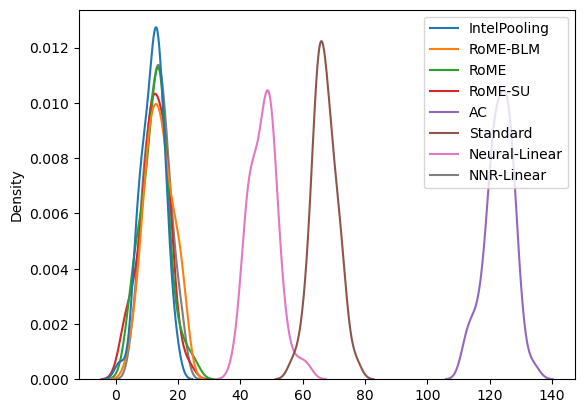

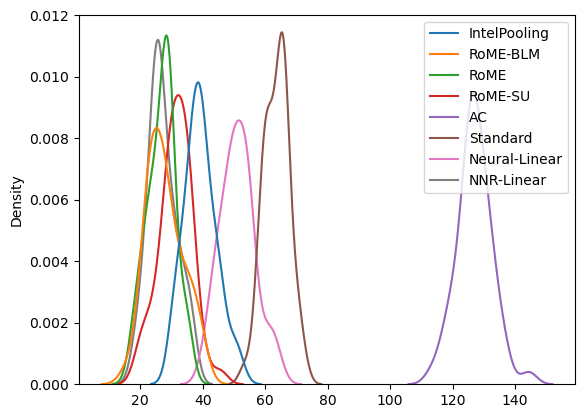

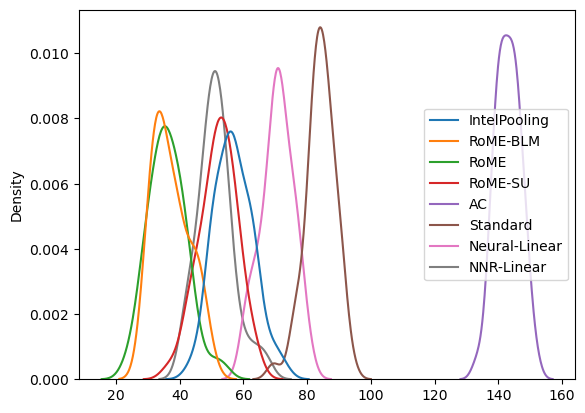

In [40]:
sns.kdeplot(data=final_homogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_heterogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_nonlinear_regret_df)
plt.show()